# Прогноз дохода банка: leakage-safe pipeline без CatBoost

Блокнот построен специально для полных файлов из папки Шаг 2: 76 786 train-строк, 73 214 test-строк и 220 исходных признаков.

Главные принципы решения:

- точная нормированная WMAE: sum(w × |y − prediction|) / sum(w);
- validation только по целым будущим месяцам;
- w используется только как sample weight и никогда как feature;
- полностью удаляется first_salary_income, отсутствующий во всём test;
- основная модель — LightGBM regression_l1 на исходной шкале target;
- отдельная модель учит точную WMAE-поправку к логичной иерархии income proxy;
- blend строится только по temporal OOF, финальная калибровка — по взвешенной медиане, а не по среднему;
- CatBoost не используется.

## 1. Зависимости и конфигурация

Полный режим рассчитан на качество. Для smoke-test перед запуском kernel можно задать FAST_MODE=1. DATA_DIR и OUTPUT_DIR также можно передать через переменные окружения.

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("lightgbm") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "lightgbm==4.6.0"])


In [2]:
import gc
import json
import os
import platform
import random
import time
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from scipy.optimize import minimize

try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

FAST_MODE = os.environ.get("FAST_MODE", "0") == "1"
MAX_ESTIMATORS = 300 if FAST_MODE else 3200
EARLY_STOPPING = 50 if FAST_MODE else 180
FINAL_SEEDS = [SEED] if FAST_MODE else [SEED, 2026]
THREADS = min(8, os.cpu_count() or 4)
RECENCY_HALF_LIFE_MONTHS = 2.5
RECENT_WINDOW_MONTHS = 4
BLEND_REGULARIZATION = 1200.0

def find_data_dir():
    if os.environ.get("DATA_DIR"):
        return Path(os.environ["DATA_DIR"]).resolve()
    candidates = [Path.cwd() / "Шаг 2", Path.cwd()]
    for candidate in candidates:
        if (candidate / "train.csv").exists() and (candidate / "test.csv").exists():
            return candidate.resolve()
    raise FileNotFoundError("Не найдены train.csv и test.csv. Укажите DATA_DIR.")

DATA_DIR = find_data_dir()
OUTPUT_DIR = Path(os.environ.get("OUTPUT_DIR", str(DATA_DIR))).resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"

print({
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "lightgbm": lgb.__version__,
    "fast_mode": FAST_MODE,
    "threads": THREADS,
    "data_dir": str(DATA_DIR),
})


{'python': '3.12.13', 'pandas': '2.2.2', 'numpy': '2.0.2', 'lightgbm': '4.6.0', 'fast_mode': False, 'threads': 2, 'data_dir': '/content'}


## 2. Загрузка и контроль схемы

In [3]:
READ_KWARGS = dict(
    sep=";",
    decimal=",",
    low_memory=False,
    na_values=["", "nan", "None", "NaN", "NULL", "null"],
    encoding="utf-8",
    encoding_errors="replace",
)

load_started = time.time()
train = pd.read_csv(TRAIN_PATH, **READ_KWARGS)
test = pd.read_csv(TEST_PATH, **READ_KWARGS)
print(f"Загрузка: {time.time() - load_started:.1f} sec")
print("train:", train.shape, "test:", test.shape)

ID_COL = "id"
DATE_COL = "dt"
TARGET_COL = "target"
WEIGHT_COL = "w"

assert {ID_COL, DATE_COL, TARGET_COL, WEIGHT_COL}.issubset(train.columns)
assert {ID_COL, DATE_COL}.issubset(test.columns)
assert set(train.columns) - {TARGET_COL, WEIGHT_COL} == set(test.columns)
assert train[ID_COL].notna().all() and test[ID_COL].notna().all()
assert train[ID_COL].is_unique and test[ID_COL].is_unique
assert set(train[ID_COL]).isdisjoint(set(test[ID_COL]))

y = pd.to_numeric(train[TARGET_COL], errors="raise").to_numpy(dtype=np.float64)
w = pd.to_numeric(train[WEIGHT_COL], errors="raise").to_numpy(dtype=np.float64)
train_dates = pd.to_datetime(train[DATE_COL], errors="raise", format="mixed", dayfirst=True)
test_dates = pd.to_datetime(test[DATE_COL], errors="raise", format="mixed", dayfirst=True)

assert np.isfinite(y).all() and np.isfinite(w).all() and (w > 0).all()
assert train_dates.max() < test_dates.min(), "Ожидался чистый future split"

display(pd.DataFrame({
    "dataset": ["train", "test"],
    "rows": [len(train), len(test)],
    "columns": [train.shape[1], test.shape[1]],
    "date_min": [train_dates.min(), test_dates.min()],
    "date_max": [train_dates.max(), test_dates.max()],
    "missing_share": [train.isna().mean().mean(), test.isna().mean().mean()],
}))


Загрузка: 8.4 sec
train: (76786, 224) test: (73214, 222)


,dataset,rows,columns,date_min,date_max,missing_share
0,train,76786,224,2024-01-31,2024-06-30,0.4166
1,test,73214,222,2024-07-31,2024-11-30,0.4131


## 3. Метрика и исследование target/weights

В этих данных вес полностью определяется target:

w = min(|target / 84017.079961 − 1|, 2.57070253).

Следовательно, строки около 84k почти не влияют на метрику, а низкий и особенно высокий хвост важны. Это не разрешает использовать w как feature: в test его нет, и это была бы прямая target leakage.

Максимальная ошибка восстановления w: 1.1102230246251565e-15
Обычная медиана target: 62,754.13
Взвешенная медиана target: 84,024.44
WMAE константы: 131,764.18
Effective sample size: 39,570 / 76,786


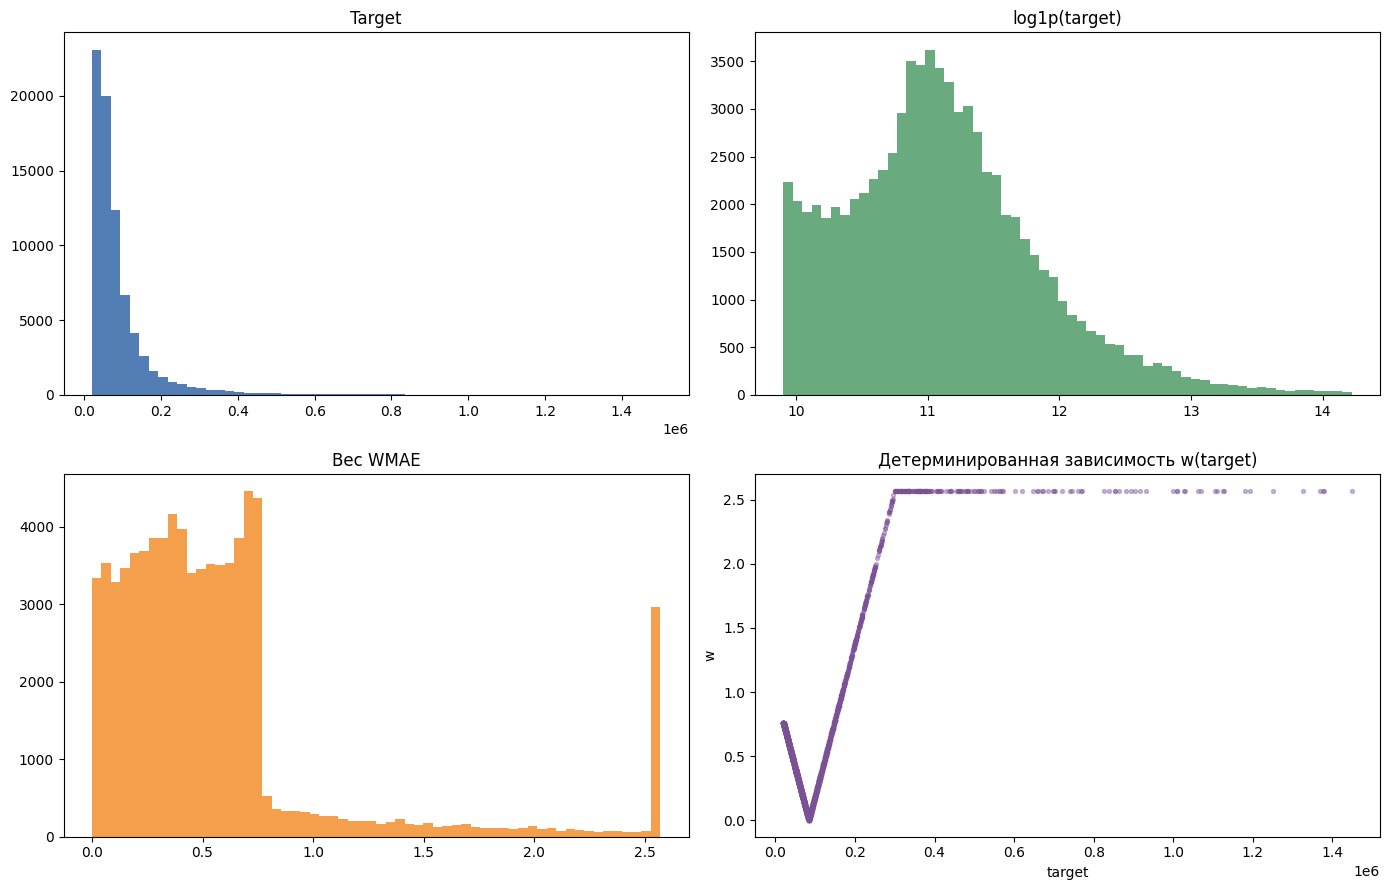

In [4]:
def wmae(y_true, y_pred, weights):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    weights = np.asarray(weights, dtype=np.float64)
    if not (len(y_true) == len(y_pred) == len(weights)):
        raise ValueError("Размеры y_true, y_pred и weights различаются")
    if not (np.isfinite(y_true).all() and np.isfinite(y_pred).all() and np.isfinite(weights).all()):
        raise ValueError("WMAE получила NaN/inf")
    if (weights < 0).any() or weights.sum() <= 0:
        raise ValueError("Некорректные веса")
    return float(np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights))

def weighted_quantile(values, quantile, weights):
    values = np.asarray(values, dtype=np.float64)
    weights = np.asarray(weights, dtype=np.float64)
    mask = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    values, weights = values[mask], weights[mask]
    order = np.argsort(values)
    values, weights = values[order], weights[order]
    position = np.searchsorted(np.cumsum(weights), quantile * weights.sum(), side="left")
    return float(values[min(position, len(values) - 1)])

def weighted_median(values, weights):
    return weighted_quantile(values, 0.5, weights)

WEIGHT_CENTER = 84017.07996115311
WEIGHT_CAP = 2.5707025302320754
reconstructed_w = np.minimum(np.abs(y / WEIGHT_CENTER - 1.0), WEIGHT_CAP)
print("Максимальная ошибка восстановления w:", np.max(np.abs(reconstructed_w - w)))

constant_prediction = weighted_median(y, w)
effective_n = w.sum() ** 2 / np.square(w).sum()
print(f"Обычная медиана target: {np.median(y):,.2f}")
print(f"Взвешенная медиана target: {constant_prediction:,.2f}")
print(f"WMAE константы: {wmae(y, np.full(len(y), constant_prediction), w):,.2f}")
print(f"Effective sample size: {effective_n:,.0f} / {len(y):,}")

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes[0, 0].hist(y, bins=60, color="#3567a8", alpha=0.85)
axes[0, 0].set_title("Target")
axes[0, 1].hist(np.log1p(y), bins=60, color="#4f9d69", alpha=0.85)
axes[0, 1].set_title("log1p(target)")
axes[1, 0].hist(w, bins=60, color="#f28e2b", alpha=0.85)
axes[1, 0].set_title("Вес WMAE")
axes[1, 1].scatter(y[::20], w[::20], s=8, alpha=0.4, color="#7a5195")
axes[1, 1].set_xlabel("target")
axes[1, 1].set_ylabel("w")
axes[1, 1].set_title("Детерминированная зависимость w(target)")
plt.tight_layout()
plt.show()


,month,rows,target_median,weighted_median,weighted_mean,weight_sum
0,2024-01,7243,"64,404.6181","124,856.0432","189,147.1843","4,429.9795"
1,2024-02,8865,"65,000.0000","120,000.0000","182,756.4341","5,293.5011"
2,2024-03,13413,"62,048.3600","70,000.0000","165,530.8437","7,497.7873"
3,2024-04,14858,"62,210.4704","72,179.0114","171,819.5893","8,352.3228"
4,2024-05,16193,"61,894.0840","69,483.7564","162,275.5985","9,076.1128"
5,2024-06,16214,"62,934.5409","74,028.1115","166,382.8143","9,042.5942"


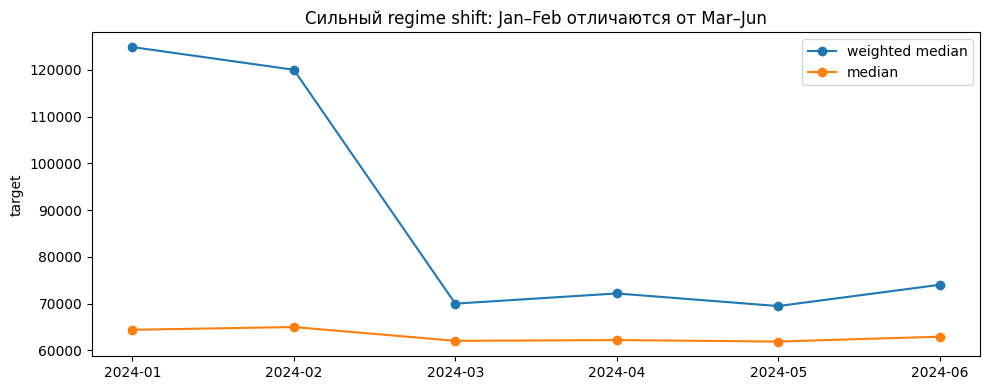

In [5]:
month_rows = []
for month in sorted(train_dates.dt.to_period("M").unique()):
    mask = (train_dates.dt.to_period("M") == month).to_numpy()
    month_rows.append({
        "month": str(month),
        "rows": int(mask.sum()),
        "target_median": np.median(y[mask]),
        "weighted_median": weighted_median(y[mask], w[mask]),
        "weighted_mean": np.average(y[mask], weights=w[mask]),
        "weight_sum": w[mask].sum(),
    })
month_summary = pd.DataFrame(month_rows)
display(month_summary)

plt.figure(figsize=(10, 4))
plt.plot(month_summary["month"], month_summary["weighted_median"], marker="o", label="weighted median")
plt.plot(month_summary["month"], month_summary["target_median"], marker="o", label="median")
plt.title("Сильный regime shift: Jan–Feb отличаются от Mar–Jun")
plt.ylabel("target")
plt.legend()
plt.tight_layout()
plt.show()


## 4. Missingness drift и доходные proxy

Самая важная практическая особенность — смена источника информации о доходе. salary_6to12m_avg очень точен, но его покрытие почти вдвое падает в test; payout и ILS, наоборот, встречаются чаще. Поэтому source_segment является полноценным признаком и маршрутизатором proxy-модели.

In [6]:
shared_features = [column for column in test.columns if column != ID_COL]
missing_audit = pd.DataFrame(index=shared_features)
missing_audit["missing_train"] = train[shared_features].isna().mean().to_numpy()
missing_audit["missing_test"] = test[shared_features].isna().mean().to_numpy()
missing_audit["shift_pp"] = 100 * (missing_audit["missing_test"] - missing_audit["missing_train"])
display(missing_audit.reindex(missing_audit["shift_pp"].abs().sort_values(ascending=False).head(25).index))

assert test["first_salary_income"].isna().all(), "Ожидалось, что first_salary_income полностью пуст в test"
print("first_salary_income missing train/test:", train["first_salary_income"].isna().mean(), test["first_salary_income"].isna().mean())

def safe_numeric(series):
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="coerce").astype(float)
    normalized = series.astype("string").str.replace(",", ".", regex=False)
    return pd.to_numeric(normalized, errors="coerce").astype(float)

proxy_columns_for_eda = [
    "salary_6to12m_avg",
    "dp_payoutincomedata_payout_avg_6_month",
    "dp_payoutincomedata_payout_avg_3_month",
    "dp_ils_avg_salary_1y",
    "dp_ils_avg_salary_2y",
    "dp_ils_paymentssum_month_avg",
    "incomeValue",
    "salary_median_in_gex_r1",
    "per_capita_income_rur_amt",
]

proxy_rows = []
for column in proxy_columns_for_eda:
    proxy_train = safe_numeric(train[column]).to_numpy()
    proxy_test = safe_numeric(test[column]).to_numpy()
    observed = np.isfinite(proxy_train) & (proxy_train > 0)
    exact_scale = weighted_median(y[observed] / proxy_train[observed], w[observed] * proxy_train[observed])
    proxy_rows.append({
        "feature": column,
        "coverage_train": observed.mean(),
        "coverage_test": (np.isfinite(proxy_test) & (proxy_test > 0)).mean(),
        "spearman": pd.Series(proxy_train[observed]).corr(pd.Series(y[observed]), method="spearman"),
        "raw_WMAE_observed": wmae(y[observed], proxy_train[observed], w[observed]),
        "optimal_scale": exact_scale,
        "scaled_WMAE_observed": wmae(y[observed], exact_scale * proxy_train[observed], w[observed]),
    })
proxy_audit = pd.DataFrame(proxy_rows).sort_values("scaled_WMAE_observed")
display(proxy_audit)


,missing_train,missing_test,shift_pp
by_category__amount__sum__eoperation_type_name__ishodjaschij_bystryj_platezh_sbp,0.5866,0.3837,-20.2881
by_category__amount__sum__eoperation_type_name__vhodjaschij_bystryj_platezh_sbp,0.6102,0.4269,-18.3237
by_category__amount__sum__eoperation_type_name__platezh_za_mobilnyj_cherez_ps,0.6805,0.5315,-14.9058
by_category__amount__sum__eoperation_type_name__perevod_mezhdu_svoimi_schetami,0.6675,0.5342,-13.3318
first_salary_income,0.8871,1.0000,11.2885
salary_6to12m_avg,0.8063,0.8957,8.9451
dp_payoutincomedata_payout_avg_prev_year,0.8975,0.8160,-8.1489
dp_ils_ipkcurrentyear_currentyearpensfactor,0.8251,0.7503,-7.4820
dp_payoutincomedata_payout_avg_6_month,0.8576,0.7900,-6.7644
dp_payoutincomedata_payout_avg_3_month,0.8576,0.7900,-6.7644


first_salary_income missing train/test: 0.8871148386424609 1.0


,feature,coverage_train,coverage_test,spearman,raw_WMAE_observed,optimal_scale,scaled_WMAE_observed
0,salary_6to12m_avg,0.1937,0.1043,0.9352,"43,985.2593",0.9236,"39,056.8767"
1,dp_payoutincomedata_payout_avg_6_month,0.1416,0.2085,0.7751,"78,899.4269",0.8387,"68,803.1209"
2,dp_payoutincomedata_payout_avg_3_month,0.1409,0.2077,0.7588,"87,394.1974",0.8052,"75,249.0772"
3,dp_ils_avg_salary_1y,0.2051,0.2609,0.6913,"86,587.7339",0.9830,"86,533.4080"
4,dp_ils_avg_salary_2y,0.2093,0.2657,0.6722,"90,852.0914",1.0742,"90,011.5238"
5,dp_ils_paymentssum_month_avg,0.2149,0.2724,0.6483,"132,998.5450",0.6312,"101,851.9952"
6,incomeValue,0.8311,0.7926,0.3918,"114,110.9414",1.2971,"110,967.0739"
8,per_capita_income_rur_amt,0.9037,0.9050,0.2063,"129,884.4468",1.4404,"126,530.5729"
7,salary_median_in_gex_r1,0.4429,0.4597,0.3577,"144,231.0317",1.8765,"132,630.2277"


## 5. Что исправлено относительно прошлых файлов

- В ряде старых notebooks использовалось mean(w × abs(error)) вместо деления на sum(w).
- Обычный TimeSeriesSplit разрезал один месяц между train и validation. Здесь каждый fold — целый следующий месяц.
- Удалены full-target encoding, random KFold, validation на уже full-fit моделях и индивидуальный w как feature.
- Категории train/test кодируются совместно и согласованно; в XGBoost-подобной отдельной кодировке здесь нет необходимости.
- first_salary_income и все его производные полностью удаляются, а не заполняются train-медианой.
- Основной objective — raw-target L1. Log-target не маскирует дорогой высокий хвост.
- Нет in-sample KNN/meta diagnostics, выдаваемых за CV. Blend получает только OOF-прогнозы.
- Калибровка основана на взвешенной медиане отношения y/prediction и проверяется на последнем месяце.

## 6. Подготовка признаков

Объединение train и test ниже используется только для согласованного распознавания типов, категорий и частот. Target и w туда не попадают. Это допустимая unsupervised transductive preprocessing; при строгом production-сценарии frequency encoding можно считать только по train.

In [7]:
EXPLICIT_CATEGORICAL = {
    "gender",
    "adminarea",
    "city_smart_name",
    "dp_ewb_last_employment_position",
    "dp_ewb_last_organization",
    "addrref",
    "dp_address_unique_regions",
    "incomeValueCategory",
}

PROXY_SOURCE_NAMES = {
    0: "weak_or_missing",
    1: "geo",
    2: "incomeValue",
    3: "ILS_payment",
    4: "ILS_salary",
    5: "payout",
    6: "salary",
}

def first_positive_by_order(frame, columns, divide_by=None):
    divide_by = divide_by or {}
    value = np.full(len(frame), np.nan, dtype=np.float64)
    source_index = np.full(len(frame), -1, dtype=np.int16)
    count = np.zeros(len(frame), dtype=np.int16)
    for index, column in enumerate(columns):
        if column not in frame.columns:
            continue
        candidate = safe_numeric(frame[column]).to_numpy() / divide_by.get(column, 1.0)
        valid = np.isfinite(candidate) & (candidate > 0)
        count += valid.astype(np.int16)
        take = ~np.isfinite(value) & valid
        value[take] = candidate[take]
        source_index[take] = index
    return value, source_index, count

def add_income_proxy_features(full):
    salary, _, salary_count = first_positive_by_order(full, ["salary_6to12m_avg"])
    payout, payout_from, payout_count = first_positive_by_order(
        full,
        [
            "dp_payoutincomedata_payout_avg_6_month",
            "dp_payoutincomedata_payout_avg_3_month",
            "dp_payoutincomedata_payout_avg_prev_year",
            "dp_payoutincomedata_payout_sum_3_month",
        ],
        divide_by={"dp_payoutincomedata_payout_sum_3_month": 3.0},
    )
    ils_salary, ils_salary_from, ils_salary_count = first_positive_by_order(
        full, ["dp_ils_avg_salary_1y", "dp_ils_avg_salary_2y", "dp_ils_avg_salary_3y"]
    )
    ils_payment, ils_payment_from, ils_payment_count = first_positive_by_order(
        full,
        [
            "dp_ils_paymentssum_month_avg",
            "dp_ils_accpayment_month_avg",
            "dp_ils_paymentssum_avg_6m",
            "dp_ils_accpayment_avg_6m",
        ],
    )
    income_value, _, income_count = first_positive_by_order(full, ["incomeValue"])
    geo, geo_from, geo_count = first_positive_by_order(
        full, ["salary_median_in_gex_r1", "per_capita_income_rur_amt"]
    )

    components = {
        "salary": salary,
        "payout": payout,
        "ils_salary": ils_salary,
        "ils_payment": ils_payment,
        "income_value": income_value,
        "geo": geo,
    }
    for name, values in components.items():
        full[f"proxy_{name}_value"] = values.astype(np.float32)
        full[f"proxy_{name}_log1p"] = np.log1p(np.nan_to_num(values, nan=0.0)).astype(np.float32)
        full[f"proxy_{name}_available"] = (np.isfinite(values) & (values > 0)).astype(np.int8)

    full["proxy_payout_from"] = payout_from.astype(np.float32)
    full["proxy_ils_salary_from"] = ils_salary_from.astype(np.float32)
    full["proxy_ils_payment_from"] = ils_payment_from.astype(np.float32)
    full["proxy_geo_from"] = geo_from.astype(np.float32)

    best_proxy = np.full(len(full), np.nan, dtype=np.float64)
    source = np.zeros(len(full), dtype=np.int8)
    confidence = np.zeros(len(full), dtype=np.float32)
    for values, code, conf in [
        (salary, 6, 0.92),
        (payout, 5, 0.84),
        (ils_salary, 4, 0.76),
        (ils_payment, 3, 0.62),
        (income_value, 2, 0.48),
        (geo, 1, 0.25),
    ]:
        take = ~np.isfinite(best_proxy) & np.isfinite(values) & (values > 0)
        best_proxy[take] = values[take]
        source[take] = code
        confidence[take] = conf

    component_matrix = np.column_stack(list(components.values()))
    available_count = np.isfinite(component_matrix).sum(axis=1)
    finite_components = np.isfinite(component_matrix)
    component_max = np.where(finite_components, component_matrix, -np.inf).max(axis=1)
    component_min = np.where(finite_components, component_matrix, np.inf).min(axis=1)
    component_max[available_count == 0] = np.nan
    component_min[available_count == 0] = np.nan

    full["best_income_proxy"] = best_proxy.astype(np.float32)
    full["best_income_proxy_log1p"] = np.log1p(np.nan_to_num(best_proxy, nan=0.0)).astype(np.float32)
    full["source_segment"] = pd.Categorical(source)
    full["proxy_confidence"] = confidence
    full["proxy_available_count"] = available_count.astype(np.float32)
    full["proxy_log_spread"] = (
        np.log1p(np.nan_to_num(component_max, nan=0.0))
        - np.log1p(np.nan_to_num(component_min, nan=0.0))
    ).astype(np.float32)

    for left, right, new_column in [
        ("incomeValue", "best_income_proxy", "ratio_incomeValue_proxy"),
        ("turn_cur_db_avg_v2", "best_income_proxy", "ratio_dbavg_proxy"),
        ("turn_cur_cr_avg_v2", "best_income_proxy", "ratio_cravg_proxy"),
        ("curr_rur_amt_cm_avg", "best_income_proxy", "ratio_balance_proxy"),
        ("hdb_bki_total_max_limit", "best_income_proxy", "ratio_bki_limit_proxy"),
        ("dp_ils_paymentssum_month_avg", "best_income_proxy", "ratio_payment_proxy"),
    ]:
        if left in full.columns:
            numerator = safe_numeric(full[left]).to_numpy()
            ratio = numerator / np.maximum(best_proxy, 1.0)
            full[new_column] = np.clip(ratio, -100, 100).astype(np.float32)

    return full, best_proxy, source

def build_features(train_frame, test_frame):
    n_train = len(train_frame)
    train_features = train_frame.drop(columns=[TARGET_COL, WEIGHT_COL]).copy()
    test_features = test_frame.copy()
    full = pd.concat([train_features, test_features], ignore_index=True)

    forbidden = [column for column in full.columns if "first_salary_income" in column]
    full = full.drop(columns=forbidden, errors="ignore")

    dt = pd.to_datetime(full[DATE_COL], errors="coerce", format="mixed", dayfirst=True)
    activity = pd.to_datetime(full["period_last_act_ad"], errors="coerce", format="mixed", dayfirst=True)
    activity = activity.mask(activity.dt.year < 2000)
    full["dt_month"] = dt.dt.month.astype(np.float32)
    full["dt_quarter"] = dt.dt.quarter.astype(np.float32)
    full["dt_month_index"] = (dt.dt.year * 12 + dt.dt.month).astype(np.float32)
    full["days_since_last_activity"] = (dt - activity).dt.days.astype(np.float32)
    full["last_activity_missing"] = activity.isna().astype(np.int8)
    full = full.drop(columns=[DATE_COL, "period_last_act_ad"], errors="ignore")

    if "dp_address_unique_regions" in full.columns:
        def canonicalize_region_list(value):
            if pd.isna(value):
                return pd.NA
            tokens = [token.strip() for token in str(value).split(",") if token.strip()]
            unique_tokens = set(tokens)
            sort_key = lambda token: (not token.isdigit(), int(token) if token.isdigit() else token)
            return ",".join(sorted(unique_tokens, key=sort_key)) if unique_tokens else pd.NA

        region_lists = full["dp_address_unique_regions"].map(canonicalize_region_list).astype("string")
        full["dp_address_unique_regions"] = region_lists
        region_present = region_lists.notna() & region_lists.str.len().gt(0)
        full["dp_address_region_count"] = (
            region_lists.str.count(",").add(1).where(region_present).astype(np.float32)
        )
        full["dp_address_first_region"] = pd.to_numeric(
            region_lists.str.split(",").str[0], errors="coerce"
        ).astype(np.float32)
        full["dp_address_multiple_regions"] = (
            full["dp_address_region_count"].fillna(0) > 1
        ).astype(np.int8)

    if "dp_ewb_last_organization" in full.columns:
        organization = full["dp_ewb_last_organization"].fillna("__MISSING__").astype(str)
        organization_count = organization.iloc[:n_train].value_counts()
        train_frequency = organization.map(organization_count).fillna(0)
        full["dp_ewb_last_organization__train_freq"] = (train_frequency / n_train).astype(np.float32)
        organization_grouped = organization.where(train_frequency >= 20, "__RARE__")
        full["dp_ewb_last_organization"] = organization_grouped.where(
            train_frequency > 0, "__UNSEEN__"
        )

    categorical_columns = []
    for column in sorted(EXPLICIT_CATEGORICAL.intersection(full.columns)):
        values = full[column].fillna("__MISSING__").astype(str)
        full[column + "__freq"] = (values.map(values.value_counts()) / len(values)).astype(np.float32)
        full[column] = pd.Categorical(values)
        categorical_columns.append(column)

    for column in list(full.select_dtypes(include="object").columns):
        if column in categorical_columns:
            continue
        numeric = safe_numeric(full[column])
        nonmissing = max(int(full[column].notna().sum()), 1)
        parse_ratio = numeric.notna().sum() / nonmissing
        if parse_ratio >= 0.995:
            full[column] = numeric.astype(np.float32)
        else:
            values = full[column].fillna("__MISSING__").astype(str)
            full[column + "__freq"] = (values.map(values.value_counts()) / len(values)).astype(np.float32)
            full[column] = pd.Categorical(values)
            categorical_columns.append(column)

    raw_numeric = [
        column for column in full.columns
        if column != ID_COL and pd.api.types.is_numeric_dtype(full[column])
    ]
    full["row_missing_count"] = full[raw_numeric].isna().sum(axis=1).astype(np.float32)
    full["row_zero_count"] = (full[raw_numeric].fillna(1) == 0).sum(axis=1).astype(np.float32)

    for family, prefixes in {
        "bki": ("hdb_bki_", "bki_"),
        "ils": ("dp_ils_",),
        "payout": ("dp_payout",),
        "turnover": ("turn_",),
        "transactions": ("transaction_", "avg_3m_", "avg_6m_"),
    }.items():
        family_columns = [column for column in raw_numeric if column.startswith(prefixes)]
        if family_columns:
            full[f"{family}__missing_count"] = full[family_columns].isna().sum(axis=1).astype(np.float32)
            full[f"{family}__available_count"] = full[family_columns].notna().sum(axis=1).astype(np.float32)

    full, best_proxy, source = add_income_proxy_features(full)
    categorical_columns.append("source_segment")

    full = full.drop(columns=[ID_COL], errors="ignore")
    drop_columns = []
    for column in full.columns:
        if full[column].nunique(dropna=False) <= 1:
            drop_columns.append(column)
        elif pd.api.types.is_numeric_dtype(full[column]) and full[column].isna().mean() > 0.997:
            drop_columns.append(column)
    full = full.drop(columns=drop_columns)
    categorical_columns = [column for column in categorical_columns if column in full.columns]

    for column in full.columns:
        if column not in categorical_columns and pd.api.types.is_numeric_dtype(full[column]):
            full[column] = full[column].replace([np.inf, -np.inf], np.nan).astype(np.float32)

    X_train = full.iloc[:n_train].reset_index(drop=True)
    X_test = full.iloc[n_train:].reset_index(drop=True)
    return (
        X_train,
        X_test,
        categorical_columns,
        best_proxy[:n_train],
        best_proxy[n_train:],
        source[:n_train],
        source[n_train:],
        sorted(set(forbidden + drop_columns)),
    )

feature_started = time.time()
X, X_test, cat_columns, proxy_train, proxy_test, source_train, source_test, dropped_columns = build_features(train, test)
print(f"Feature engineering: {time.time() - feature_started:.1f} sec")
print("X:", X.shape, "X_test:", X_test.shape)
print("categorical:", cat_columns)
print("dropped:", dropped_columns)

assert list(X.columns) == list(X_test.columns)
assert not any("first_salary_income" in column for column in X.columns)
assert not {ID_COL, DATE_COL, TARGET_COL, WEIGHT_COL}.intersection(X.columns)
assert len(X) == len(y) and len(X_test) == len(test)


Feature engineering: 7.6 sec
X: (76786, 281) X_test: (73214, 281)
categorical: ['addrref', 'adminarea', 'city_smart_name', 'dp_address_unique_regions', 'dp_ewb_last_employment_position', 'dp_ewb_last_organization', 'gender', 'incomeValueCategory', 'source_segment']
dropped: ['first_salary_income']


## 7. Expanding target encoding только из прошлого

Для категорий добавляется сглаженное weighted-mean encoding. Значение train-строки использует только более ранние месяцы; test использует всю историю train. Таким образом validation target никогда не попадает в её признаки.

In [8]:
def add_past_target_encoding(X_train, X_future, categories, target, weights, dates, smoothing=120.0):
    X_train = X_train.copy()
    X_future = X_future.copy()
    dates = pd.to_datetime(dates)
    ordered_dates = np.sort(dates.unique())
    selected = [
        column for column in categories
        if column in {"gender", "adminarea", "city_smart_name", "dp_ewb_last_employment_position", "source_segment"}
    ]

    for column in selected:
        train_values = X_train[column].astype(str)
        future_values = X_future[column].astype(str)
        encoded = np.full(len(X_train), np.nan, dtype=np.float64)

        for current_date in ordered_dates:
            history = (dates < current_date).to_numpy()
            current = (dates == current_date).to_numpy()
            if history.sum() == 0:
                continue
            prior = np.average(target[history], weights=weights[history])
            table = pd.DataFrame({
                "key": train_values[history].to_numpy(),
                "wy": weights[history] * target[history],
                "weight": weights[history],
            }).groupby("key", observed=True)[["wy", "weight"]].sum()
            mapping = (table["wy"] + prior * smoothing) / (table["weight"] + smoothing)
            encoded[current] = train_values[current].map(mapping).fillna(prior).to_numpy()

        prior = np.average(target, weights=weights)
        table = pd.DataFrame({
            "key": train_values.to_numpy(),
            "wy": weights * target,
            "weight": weights,
        }).groupby("key", observed=True)[["wy", "weight"]].sum()
        mapping = (table["wy"] + prior * smoothing) / (table["weight"] + smoothing)
        X_train[column + "__past_te"] = encoded.astype(np.float32)
        X_future[column + "__past_te"] = future_values.map(mapping).fillna(prior).astype(np.float32)

    return X_train, X_future, selected

X, X_test, te_columns = add_past_target_encoding(X, X_test, cat_columns, y, w, train_dates)
print("Past-only target encodings:", te_columns)
print("Final feature count:", X.shape[1])

source_audit = pd.DataFrame({
    "source": list(PROXY_SOURCE_NAMES.values()),
    "train_share": [np.mean(source_train == code) for code in PROXY_SOURCE_NAMES],
    "test_share": [np.mean(source_test == code) for code in PROXY_SOURCE_NAMES],
})
source_audit["shift_pp"] = 100 * (source_audit["test_share"] - source_audit["train_share"])
display(source_audit)


Past-only target encodings: ['adminarea', 'city_smart_name', 'dp_ewb_last_employment_position', 'gender', 'source_segment']
Final feature count: 286


,source,train_share,test_share,shift_pp
0,weak_or_missing,0.0585,0.0664,0.7895
1,geo,0.0992,0.1271,2.7884
2,incomeValue,0.4895,0.4545,-3.4920
3,ILS_payment,0.0030,0.0041,0.1169
4,ILS_salary,0.0517,0.0530,0.1347
5,payout,0.1044,0.1905,8.6076
6,salary,0.1937,0.1043,-8.9451


## 8. Whole-month expanding CV

Folds: Jan–Feb → Mar, Jan–Mar → Apr, Jan–Apr → May, Jan–May → Jun. Последний June fold наиболее близок к test и выводится отдельно.

In [9]:
train_periods = train_dates.dt.to_period("M")
period_ordinals = train_periods.astype(int).to_numpy()
unique_periods = sorted(train_periods.unique())
validation_periods = unique_periods[2:]

time_folds = []
for valid_period in validation_periods:
    train_index = np.flatnonzero((train_periods < valid_period).to_numpy())
    valid_index = np.flatnonzero((train_periods == valid_period).to_numpy())
    time_folds.append((train_index, valid_index, str(valid_period)))

display(pd.DataFrame([
    {
        "valid_month": month,
        "n_train": len(train_index),
        "n_valid": len(valid_index),
        "valid_weight_sum": w[valid_index].sum(),
    }
    for train_index, valid_index, month in time_folds
]))


,valid_month,n_train,n_valid,valid_weight_sum
0,2024-03,16108,13413,"7,497.7873"
1,2024-04,29521,14858,"8,352.3228"
2,2024-05,44379,16193,"9,076.1128"
3,2024-06,60572,16214,"9,042.5942"


## 9. Модели

Кандидаты ансамбля:

1. direct_all — weighted L1 на всей доступной истории;
2. direct_decay — та же модель с плавным recency decay;
3. proxy_ratio_all — модель коэффициента y/proxy;
4. proxy_ratio_recent — коэффициент по последним четырём месяцам;
5. proxy_table — простой source-specific коэффициент как устойчивый baseline.

Для положительного proxy p модель ratio строго согласована с метрикой:

w × |y − p × r| = w × p × |y/p − r|.

Поэтому ratio обучается с label y/p и весом w×p.

In [10]:
PREDICTION_MIN = float(np.min(y))
PREDICTION_MAX = float(np.max(y))
MODEL_NAMES = ["direct_all", "direct_decay", "proxy_ratio_all", "proxy_ratio_recent", "proxy_table"]
LEARNED_MODEL_NAMES = MODEL_NAMES[:-1]

def clip_prediction(prediction):
    return np.clip(np.asarray(prediction, dtype=np.float64), PREDICTION_MIN, PREDICTION_MAX)

def normalize_weights(weights, reference):
    weights = np.asarray(weights, dtype=np.float64)
    reference = np.asarray(reference, dtype=np.float64)
    return weights * (reference.mean() / max(weights.mean(), 1e-12))

def recency_multiplier(indices):
    age_months = period_ordinals[indices].max() - period_ordinals[indices]
    return np.power(0.5, age_months / RECENCY_HALF_LIFE_MONTHS)

def recent_indices(indices, n_months=RECENT_WINDOW_MONTHS):
    available = sorted(train_periods.iloc[indices].unique())
    selected = set(available[-n_months:])
    return indices[train_periods.iloc[indices].isin(selected).to_numpy()]

def make_lgbm(seed, n_estimators=MAX_ESTIMATORS, num_leaves=95):
    return LGBMRegressor(
        objective="regression_l1",
        n_estimators=int(n_estimators),
        learning_rate=0.035,
        num_leaves=num_leaves,
        min_child_samples=70,
        subsample=0.85,
        subsample_freq=1,
        colsample_bytree=0.80,
        reg_alpha=0.3,
        reg_lambda=12.0,
        max_bin=255,
        importance_type="gain",
        random_state=seed,
        deterministic=True,
        force_col_wise=True,
        n_jobs=THREADS,
        verbosity=-1,
    )

def fit_with_validation(model, X_train_part, label_train, weight_train, X_valid_part, label_valid, weight_valid):
    model.fit(
        X_train_part,
        label_train,
        sample_weight=weight_train,
        eval_set=[(X_valid_part, label_valid)],
        eval_sample_weight=[weight_valid],
        eval_metric="l1",
        categorical_feature=cat_columns,
        callbacks=[lgb.early_stopping(EARLY_STOPPING, verbose=False), lgb.log_evaluation(0)],
    )
    return model

def fit_source_scale(proxy, target, weights, source, shrink=700.0):
    proxy = np.asarray(proxy, dtype=np.float64)
    target = np.asarray(target, dtype=np.float64)
    weights = np.asarray(weights, dtype=np.float64)
    source = np.asarray(source, dtype=int)
    valid = np.isfinite(proxy) & (proxy > 0)
    exact_weights = weights[valid] * proxy[valid]
    global_scale = weighted_median(target[valid] / proxy[valid], exact_weights)
    factors = {}
    for code in PROXY_SOURCE_NAMES:
        mask = valid & (source == code)
        if mask.sum() < 100:
            factors[code] = global_scale
            continue
        local_weights = weights[mask] * proxy[mask]
        local_scale = weighted_median(target[mask] / proxy[mask], local_weights)
        normalized_mass = local_weights.sum() / max(local_weights.mean(), 1e-12)
        strength = normalized_mass / (normalized_mass + shrink)
        factors[code] = strength * local_scale + (1.0 - strength) * global_scale
    return global_scale, factors

def apply_source_scale(proxy, source, global_scale, factors, fallback):
    prediction = np.asarray(fallback, dtype=np.float64).copy()
    proxy = np.asarray(proxy, dtype=np.float64)
    source = np.asarray(source, dtype=int)
    valid = np.isfinite(proxy) & (proxy > 0)
    local_factor = np.array([factors.get(int(code), global_scale) for code in source[valid]])
    prediction[valid] = proxy[valid] * local_factor
    return clip_prediction(prediction)


In [11]:
oof = {name: np.full(len(y), np.nan, dtype=np.float64) for name in MODEL_NAMES}
best_iterations = {name: [] for name in LEARNED_MODEL_NAMES}
fold_rows = []
importance_rows = []

for fold_number, (train_index, valid_index, valid_month) in enumerate(time_folds, 1):
    print(f"\n=== Fold {fold_number}: validate {valid_month} ===")
    X_train_fold = X.iloc[train_index]
    X_valid_fold = X.iloc[valid_index]

    direct_all = make_lgbm(SEED + fold_number, num_leaves=95)
    direct_all = fit_with_validation(
        direct_all, X_train_fold, y[train_index], w[train_index],
        X_valid_fold, y[valid_index], w[valid_index],
    )
    pred_direct = clip_prediction(direct_all.predict(X_valid_fold))
    oof["direct_all"][valid_index] = pred_direct
    best_iterations["direct_all"].append(int(direct_all.best_iteration_ or MAX_ESTIMATORS))
    importance_rows.append(pd.DataFrame({"feature": X.columns, "gain": direct_all.feature_importances_, "fold": fold_number}))

    decay_weights = w[train_index] * recency_multiplier(train_index)
    decay_weights = normalize_weights(decay_weights, w[train_index])
    direct_decay = make_lgbm(SEED + 100 + fold_number, num_leaves=95)
    direct_decay = fit_with_validation(
        direct_decay, X_train_fold, y[train_index], decay_weights,
        X_valid_fold, y[valid_index], w[valid_index],
    )
    oof["direct_decay"][valid_index] = clip_prediction(direct_decay.predict(X_valid_fold))
    best_iterations["direct_decay"].append(int(direct_decay.best_iteration_ or MAX_ESTIMATORS))

    valid_proxy_train = np.isfinite(proxy_train[train_index]) & (proxy_train[train_index] > 0)
    valid_proxy_valid = np.isfinite(proxy_train[valid_index]) & (proxy_train[valid_index] > 0)
    ratio_train_index = train_index[valid_proxy_train]
    ratio_valid_index = valid_index[valid_proxy_valid]

    ratio_target_train = y[ratio_train_index] / proxy_train[ratio_train_index]
    ratio_target_valid = y[ratio_valid_index] / proxy_train[ratio_valid_index]
    ratio_weight_train = normalize_weights(w[ratio_train_index] * proxy_train[ratio_train_index], w[ratio_train_index])
    ratio_weight_valid = normalize_weights(w[ratio_valid_index] * proxy_train[ratio_valid_index], w[ratio_valid_index])

    ratio_all = make_lgbm(SEED + 200 + fold_number, num_leaves=63)
    ratio_all = fit_with_validation(
        ratio_all, X.iloc[ratio_train_index], ratio_target_train, ratio_weight_train,
        X.iloc[ratio_valid_index], ratio_target_valid, ratio_weight_valid,
    )
    ratio_prediction = pred_direct.copy()
    ratio_prediction[valid_proxy_valid] = (
        proxy_train[ratio_valid_index] * ratio_all.predict(X.iloc[ratio_valid_index])
    )
    oof["proxy_ratio_all"][valid_index] = clip_prediction(ratio_prediction)
    best_iterations["proxy_ratio_all"].append(int(ratio_all.best_iteration_ or MAX_ESTIMATORS))

    recent_train_index = recent_indices(train_index)
    recent_good = np.isfinite(proxy_train[recent_train_index]) & (proxy_train[recent_train_index] > 0)
    recent_ratio_index = recent_train_index[recent_good]
    recent_ratio_target = y[recent_ratio_index] / proxy_train[recent_ratio_index]
    recent_ratio_weight = normalize_weights(w[recent_ratio_index] * proxy_train[recent_ratio_index], w[recent_ratio_index])
    ratio_recent = make_lgbm(SEED + 300 + fold_number, num_leaves=63)
    ratio_recent = fit_with_validation(
        ratio_recent, X.iloc[recent_ratio_index], recent_ratio_target, recent_ratio_weight,
        X.iloc[ratio_valid_index], ratio_target_valid, ratio_weight_valid,
    )
    recent_ratio_prediction = pred_direct.copy()
    recent_ratio_prediction[valid_proxy_valid] = (
        proxy_train[ratio_valid_index] * ratio_recent.predict(X.iloc[ratio_valid_index])
    )
    oof["proxy_ratio_recent"][valid_index] = clip_prediction(recent_ratio_prediction)
    best_iterations["proxy_ratio_recent"].append(int(ratio_recent.best_iteration_ or MAX_ESTIMATORS))

    global_scale, source_scales = fit_source_scale(
        proxy_train[train_index], y[train_index], w[train_index], source_train[train_index]
    )
    oof["proxy_table"][valid_index] = apply_source_scale(
        proxy_train[valid_index], source_train[valid_index], global_scale, source_scales, pred_direct
    )

    for name in MODEL_NAMES:
        score = wmae(y[valid_index], oof[name][valid_index], w[valid_index])
        fold_rows.append({"fold": fold_number, "valid_month": valid_month, "model": name, "WMAE": score})
        print(f"{name:22s} WMAE={score:,.2f}")

fold_scores = pd.DataFrame(fold_rows)
display(fold_scores.pivot(index="valid_month", columns="model", values="WMAE"))



=== Fold 1: validate 2024-03 ===
direct_all             WMAE=65,296.49
direct_decay           WMAE=66,330.69
proxy_ratio_all        WMAE=67,735.21
proxy_ratio_recent     WMAE=67,588.07
proxy_table            WMAE=80,921.16

=== Fold 2: validate 2024-04 ===
direct_all             WMAE=63,319.82
direct_decay           WMAE=63,444.99
proxy_ratio_all        WMAE=66,705.87
proxy_ratio_recent     WMAE=66,516.75
proxy_table            WMAE=82,957.75

=== Fold 3: validate 2024-05 ===
direct_all             WMAE=59,680.52
direct_decay           WMAE=59,847.02
proxy_ratio_all        WMAE=64,194.97
proxy_ratio_recent     WMAE=64,127.49
proxy_table            WMAE=78,570.90

=== Fold 4: validate 2024-06 ===
direct_all             WMAE=60,499.85
direct_decay           WMAE=60,547.30
proxy_ratio_all        WMAE=64,966.30
proxy_ratio_recent     WMAE=65,312.02
proxy_table            WMAE=80,936.31


model,direct_all,direct_decay,proxy_ratio_all,proxy_ratio_recent,proxy_table
valid_month,,,,,
2024-03,"65,296.4862","66,330.6889","67,735.2102","67,588.0711","80,921.1592"
2024-04,"63,319.8150","63,444.9861","66,705.8679","66,516.7525","82,957.7483"
2024-05,"59,680.5155","59,847.0172","64,194.9678","64,127.4855","78,570.9040"
2024-06,"60,499.8515","60,547.2985","64,966.3002","65,312.0169","80,936.3117"


## 10. OOF blend и test-like source reweighting

Blend настраивается на Mar–May, а June сначала остаётся контрольным месяцем. В objective мягко учитывается реальная смена source mix между OOF и test; коэффициенты ограничены, неотрицательны и суммируются в 1.

In [12]:
oof_mask = np.logical_and.reduce([np.isfinite(oof[name]) for name in MODEL_NAMES])
oof_matrix = np.column_stack([oof[name][oof_mask] for name in MODEL_NAMES])
oof_target = y[oof_mask]
oof_weight = w[oof_mask]
oof_source = source_train[oof_mask]
oof_month = train_periods[oof_mask].astype(str).to_numpy()

def test_like_weights(base_weights, source_reference, source_future, power=0.5):
    base_weights = np.asarray(base_weights, dtype=np.float64)
    source_reference = np.asarray(source_reference, dtype=int)
    source_future = np.asarray(source_future, dtype=int)
    reference_share = pd.Series(source_reference).value_counts(normalize=True)
    future_share = pd.Series(source_future).value_counts(normalize=True)
    multiplier = {
        code: float(np.clip((future_share.get(code, 1e-6) / reference_share.get(code, 1e-6)) ** power, 0.60, 1.80))
        for code in PROXY_SOURCE_NAMES
    }
    adjusted = base_weights * np.array([multiplier.get(int(code), 1.0) for code in source_reference])
    return normalize_weights(adjusted, base_weights)

def optimize_blend(prediction_matrix, target, weights, prior, regularization=BLEND_REGULARIZATION):
    prediction_matrix = np.asarray(prediction_matrix, dtype=np.float64)
    prior = np.asarray(prior, dtype=np.float64)
    prior = prior / prior.sum()

    def objective(coefficients):
        return wmae(target, prediction_matrix @ coefficients, weights) + regularization * np.square(coefficients - prior).sum()

    starts = [prior, np.full(len(prior), 1.0 / len(prior))]
    starts.extend(np.eye(len(prior)))
    best = None
    for start in starts:
        result = minimize(
            objective,
            start,
            method="SLSQP",
            bounds=[(0.0, 1.0)] * len(prior),
            constraints={"type": "eq", "fun": lambda coefficients: coefficients.sum() - 1.0},
            options={"maxiter": 300, "ftol": 1e-7},
        )
        if result.success and (best is None or result.fun < best.fun):
            best = result
    if best is None:
        return prior
    coefficients = np.clip(best.x, 0, 1)
    return coefficients / coefficients.sum()

latest_month = str(max(validation_periods))
tuning_mask = oof_month != latest_month
audit_mask = oof_month == latest_month
blend_prior = np.array([0.35, 0.25, 0.18, 0.12, 0.10])

tuning_test_like_weight = test_like_weights(
    oof_weight[tuning_mask], oof_source[tuning_mask], source_test
)
tuning_coefficients = optimize_blend(
    oof_matrix[tuning_mask], oof_target[tuning_mask], tuning_test_like_weight, blend_prior
)
audit_prediction = clip_prediction(oof_matrix[audit_mask] @ tuning_coefficients)

print("Tuning coefficients:", dict(zip(MODEL_NAMES, tuning_coefficients.round(4))))
print("June honest-ish audit WMAE:", wmae(oof_target[audit_mask], audit_prediction, oof_weight[audit_mask]))

full_test_like_weight = test_like_weights(oof_weight, oof_source, source_test)
final_blend_coefficients = optimize_blend(
    oof_matrix, oof_target, full_test_like_weight, tuning_coefficients, regularization=1800.0
)
blend_oof = clip_prediction(oof_matrix @ final_blend_coefficients)
print("Final OOF coefficients:", dict(zip(MODEL_NAMES, final_blend_coefficients.round(4))))
print("Pooled OOF blend-fit diagnostic (not nested CV):", wmae(oof_target, blend_oof, oof_weight))

single_scores = pd.DataFrame([
    {"model": name, "pooled_OOF_WMAE": wmae(oof_target, oof_matrix[:, index], oof_weight)}
    for index, name in enumerate(MODEL_NAMES)
]).sort_values("pooled_OOF_WMAE")
display(single_scores)


Tuning coefficients: {'direct_all': np.float64(0.4828), 'direct_decay': np.float64(0.3185), 'proxy_ratio_all': np.float64(0.0986), 'proxy_ratio_recent': np.float64(0.1001), 'proxy_table': np.float64(0.0)}
June honest-ish audit WMAE: 60234.62174615728
Final OOF coefficients: {'direct_all': np.float64(0.517), 'direct_decay': np.float64(0.3363), 'proxy_ratio_all': np.float64(0.0639), 'proxy_ratio_recent': np.float64(0.0828), 'proxy_table': np.float64(0.0)}
Pooled OOF blend-fit diagnostic (not nested CV): 61758.13110879057


,model,pooled_OOF_WMAE
0,direct_all,"62,033.0520"
1,direct_decay,"62,349.2223"
3,proxy_ratio_recent,"65,794.1288"
2,proxy_ratio_all,"65,799.1060"
4,proxy_table,"80,797.9899"


## 11. Source-aware multiplicative calibration

Коэффициенты к prediction вычисляются как weighted median y/prediction с весом w×prediction — это точный оптимум WMAE для масштаба. Калибратор обучается на Mar–May и единожды проверяется на June; затем переобучается на всех OOF для test.

In [13]:
def fit_prediction_scale(prediction, target, weights, source, shrink=1200.0):
    prediction = np.asarray(prediction, dtype=np.float64)
    target = np.asarray(target, dtype=np.float64)
    weights = np.asarray(weights, dtype=np.float64)
    source = np.asarray(source, dtype=int)
    exact_weights = weights * np.maximum(prediction, 1.0)
    global_factor = weighted_median(target / np.maximum(prediction, 1.0), exact_weights)
    source_factors = {}
    for code in PROXY_SOURCE_NAMES:
        mask = source == code
        if mask.sum() < 100:
            source_factors[code] = global_factor
            continue
        local_weights = exact_weights[mask]
        local_factor = weighted_median(target[mask] / np.maximum(prediction[mask], 1.0), local_weights)
        normalized_mass = local_weights.sum() / max(local_weights.mean(), 1e-12)
        local_strength = normalized_mass / (normalized_mass + shrink)
        source_factors[code] = local_strength * local_factor + (1 - local_strength) * global_factor
    return global_factor, source_factors

def apply_prediction_scale(prediction, source, global_factor, source_factors, strength=1.0):
    source = np.asarray(source, dtype=int)
    factors = np.array([source_factors.get(int(code), global_factor) for code in source])
    factors = 1.0 + strength * (factors - 1.0)
    return clip_prediction(np.asarray(prediction) * factors)

tuning_blend_all = clip_prediction(oof_matrix @ tuning_coefficients)
scale_global, scale_by_source = fit_prediction_scale(
    tuning_blend_all[tuning_mask], oof_target[tuning_mask], oof_weight[tuning_mask], oof_source[tuning_mask]
)

calibration_rows = []
for strength in [0.0, 0.25, 0.50, 0.75, 1.0]:
    candidate = apply_prediction_scale(
        tuning_blend_all[audit_mask], oof_source[audit_mask], scale_global, scale_by_source, strength
    )
    calibration_rows.append({
        "strength": strength,
        "June_WMAE": wmae(oof_target[audit_mask], candidate, oof_weight[audit_mask]),
    })
calibration_report = pd.DataFrame(calibration_rows)
display(calibration_report)
CALIBRATION_STRENGTH = float(calibration_report.sort_values("June_WMAE").iloc[0]["strength"])
print("Selected calibration strength:", CALIBRATION_STRENGTH)

final_scale_global, final_scale_by_source = fit_prediction_scale(
    blend_oof, oof_target, oof_weight, oof_source
)
calibrated_oof_diagnostic = apply_prediction_scale(
    blend_oof, oof_source, final_scale_global, final_scale_by_source, CALIBRATION_STRENGTH
)
print("Calibrated OOF in-sample diagnostic, not a new CV estimate:", wmae(oof_target, calibrated_oof_diagnostic, oof_weight))


,strength,June_WMAE
0,0.0000,"60,234.6217"
1,0.2500,"60,207.1741"
2,0.5000,"60,196.3701"
3,0.7500,"60,199.7460"
4,1.0000,"60,216.6347"


Selected calibration strength: 0.5
Calibrated OOF in-sample diagnostic, not a new CV estimate: 61680.25843827959


## 12. Финальное обучение

In [14]:
iteration_plan = {
    name: int(np.clip(round(np.median(best_iterations[name]) * 1.05), 1, MAX_ESTIMATORS))
    for name in LEARNED_MODEL_NAMES
}
print("Iteration plan:", iteration_plan)

test_predictions = {}
final_direct_models = []

seed_predictions = []
for seed in FINAL_SEEDS:
    model = make_lgbm(seed, iteration_plan["direct_all"], num_leaves=95)
    model.fit(X, y, sample_weight=w, categorical_feature=cat_columns, callbacks=[lgb.log_evaluation(0)])
    seed_predictions.append(model.predict(X_test))
    final_direct_models.append(model)
test_predictions["direct_all"] = clip_prediction(np.mean(seed_predictions, axis=0))

final_decay_weight = normalize_weights(w * recency_multiplier(np.arange(len(y))), w)
seed_predictions = []
for seed in FINAL_SEEDS:
    model = make_lgbm(seed + 100, iteration_plan["direct_decay"], num_leaves=95)
    model.fit(X, y, sample_weight=final_decay_weight, categorical_feature=cat_columns, callbacks=[lgb.log_evaluation(0)])
    seed_predictions.append(model.predict(X_test))
test_predictions["direct_decay"] = clip_prediction(np.mean(seed_predictions, axis=0))

all_indices = np.arange(len(y))
good_all = np.isfinite(proxy_train) & (proxy_train > 0)
ratio_label_all = y[good_all] / proxy_train[good_all]
ratio_weight_all = normalize_weights(w[good_all] * proxy_train[good_all], w[good_all])
good_test = np.isfinite(proxy_test) & (proxy_test > 0)

seed_predictions = []
for seed in FINAL_SEEDS:
    model = make_lgbm(seed + 200, iteration_plan["proxy_ratio_all"], num_leaves=63)
    model.fit(X.loc[good_all], ratio_label_all, sample_weight=ratio_weight_all, categorical_feature=cat_columns, callbacks=[lgb.log_evaluation(0)])
    candidate = test_predictions["direct_all"].copy()
    candidate[good_test] = proxy_test[good_test] * model.predict(X_test.loc[good_test])
    seed_predictions.append(candidate)
test_predictions["proxy_ratio_all"] = clip_prediction(np.mean(seed_predictions, axis=0))

recent_all_indices = recent_indices(all_indices)
recent_good_mask = np.isfinite(proxy_train[recent_all_indices]) & (proxy_train[recent_all_indices] > 0)
recent_good_indices = recent_all_indices[recent_good_mask]
recent_ratio_label = y[recent_good_indices] / proxy_train[recent_good_indices]
recent_ratio_weight = normalize_weights(w[recent_good_indices] * proxy_train[recent_good_indices], w[recent_good_indices])
seed_predictions = []
for seed in FINAL_SEEDS:
    model = make_lgbm(seed + 300, iteration_plan["proxy_ratio_recent"], num_leaves=63)
    model.fit(X.iloc[recent_good_indices], recent_ratio_label, sample_weight=recent_ratio_weight, categorical_feature=cat_columns, callbacks=[lgb.log_evaluation(0)])
    candidate = test_predictions["direct_all"].copy()
    candidate[good_test] = proxy_test[good_test] * model.predict(X_test.loc[good_test])
    seed_predictions.append(candidate)
test_predictions["proxy_ratio_recent"] = clip_prediction(np.mean(seed_predictions, axis=0))

proxy_global_scale, proxy_source_scales = fit_source_scale(proxy_train, y, w, source_train)
test_predictions["proxy_table"] = apply_source_scale(
    proxy_test, source_test, proxy_global_scale, proxy_source_scales, test_predictions["direct_all"]
)

test_matrix = np.column_stack([test_predictions[name] for name in MODEL_NAMES])
raw_test_blend = clip_prediction(test_matrix @ final_blend_coefficients)
final_prediction = apply_prediction_scale(
    raw_test_blend,
    source_test,
    final_scale_global,
    final_scale_by_source,
    CALIBRATION_STRENGTH,
)

display(pd.Series(final_prediction, name="predict").describe(percentiles=[0.01, 0.05, 0.10, 0.50, 0.90, 0.95, 0.99]))


Iteration plan: {'direct_all': 1235, 'direct_decay': 1243, 'proxy_ratio_all': 914, 'proxy_ratio_recent': 993}


,predict
count,"73,214.0000"
mean,"97,133.9226"
std,"94,985.2853"
min,"20,000.0000"
1%,"24,111.7264"
5%,"29,323.1469"
10%,"32,940.4454"
50%,"63,856.8394"
90%,"196,637.6035"
95%,"270,450.8397"


## 13. Submission и проверки

sample_submission.csv в папке не обязателен. Если его нет, создаются ровно id и predict в исходном порядке test.

In [15]:
sample_path = DATA_DIR / "sample_submission.csv"
if sample_path.exists():
    sample = pd.read_csv(sample_path)
    assert len(sample) == len(test)
    submission = sample.copy()
    submission["id"] = test[ID_COL].to_numpy()
    submission["predict"] = final_prediction
    submission = submission[["id", "predict"]]
else:
    submission = pd.DataFrame({"id": test[ID_COL].to_numpy(), "predict": final_prediction})

assert list(submission.columns) == ["id", "predict"]
assert len(submission) == len(test)
assert submission["id"].astype(str).tolist() == test[ID_COL].astype(str).tolist()
assert submission["id"].is_unique and submission["id"].notna().all()
assert np.isfinite(submission["predict"]).all()
assert submission["predict"].between(PREDICTION_MIN, PREDICTION_MAX).all()

submission_path = OUTPUT_DIR / "submission_ideal_no_catboost.csv"
submission.to_csv(submission_path, index=False)
print("Saved:", submission_path)
display(submission.head(10))


Saved: /content/submission_ideal_no_catboost.csv


,id,predict
0,0,"59,343.9285"
1,1,"49,650.2168"
2,3,"30,431.8770"
3,9,"71,300.3962"
4,11,"44,819.0620"
5,12,"154,332.1718"
6,13,"57,282.6535"
7,15,"149,941.2028"
8,16,"35,838.8154"
9,17,"34,028.9346"


## 14. Feature importance и финальная диагностика

,rows,mean,median,p10,p90
month,,,,,
2024-07,16795,"94,655.0438","63,635.0342","33,003.5721","190,712.8293"
2024-08,14646,"97,809.4369","64,582.0776","32,978.4501","197,017.5953"
2024-09,15501,"97,239.0458","64,259.8579","33,014.2511","194,961.9340"
2024-10,12598,"98,516.8866","64,139.8869","32,904.0605","199,786.5139"
2024-11,13674,"98,061.7484","62,658.7357","32,821.0213","201,799.2159"


source,ILS_payment,ILS_salary,geo,incomeValue,payout,salary,weak_or_missing
month,,,,,,,
2024-07,0.0040,0.0482,0.1228,0.4699,0.1515,0.1379,0.0657
2024-08,0.0038,0.0546,0.1271,0.4352,0.1864,0.1312,0.0617
2024-09,0.0037,0.0544,0.1335,0.4361,0.2076,0.1010,0.0637
2024-10,0.0052,0.0566,0.1268,0.4617,0.2069,0.0696,0.0732
2024-11,0.0042,0.0524,0.1254,0.4707,0.2082,0.0698,0.0691


,feature,importance
270,best_income_proxy_log1p,"229,862.2034"
269,best_income_proxy,"197,655.8348"
0,turn_cur_cr_avg_act_v2,"95,055.5546"
36,city_smart_name,"74,341.8792"
8,adminarea,"70,844.2709"
43,dp_ewb_last_employment_position,"52,361.6618"
17,turn_cur_db_avg_act_v2,"50,884.5767"
9,turn_cur_cr_avg_v2,"43,109.4357"
1,salary_6to12m_avg,"40,629.9923"
2,hdb_bki_total_max_limit,"36,884.1375"


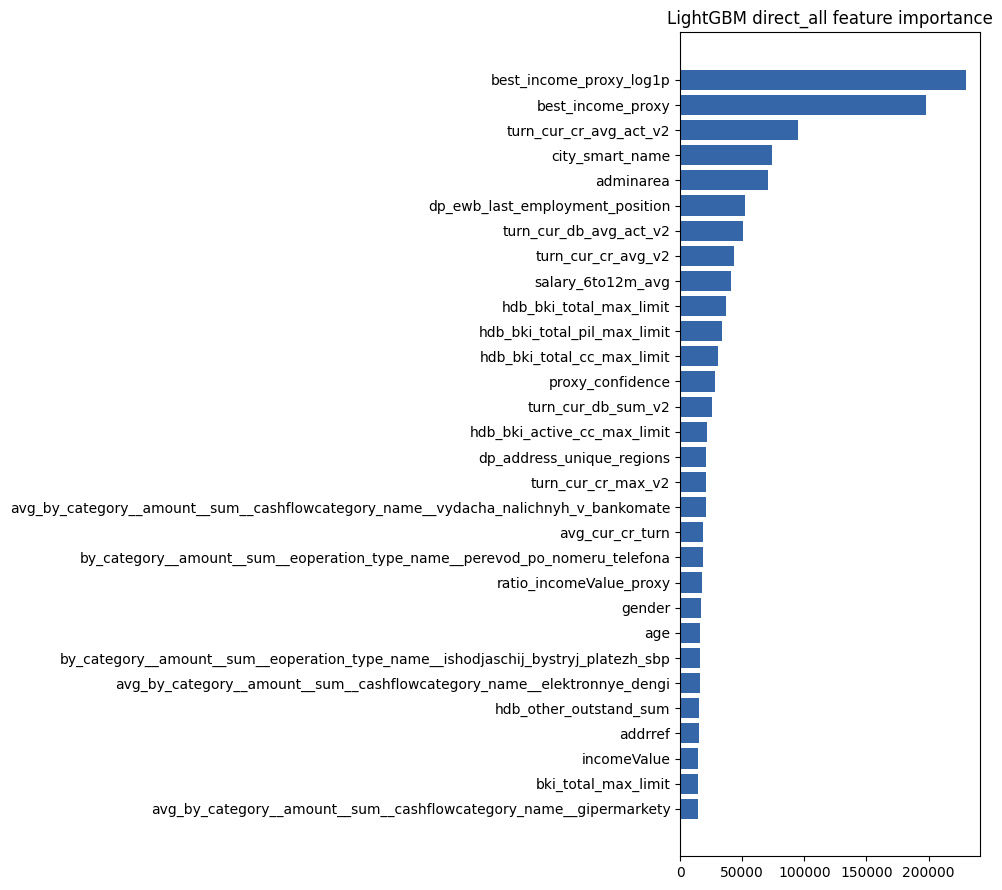

,slice,rows,weight_share,blend_WMAE
0,below_50k,21560,0.3822,"22,442.2656"
1,50k_to_150k,31838,0.2403,"31,954.5441"
2,150k_to_300k,5088,0.2116,"65,577.7191"
3,above_300k,2192,0.1659,"190,650.1320"


Готово. Для дальнейших экспериментов сравнивайте идеи на тех же whole-month folds и отдельно на June.


In [16]:
test_month_report = pd.DataFrame({
    "month": test_dates.dt.to_period("M").astype(str),
    "prediction": final_prediction,
    "source": [PROXY_SOURCE_NAMES[int(code)] for code in source_test],
})
prediction_stability = test_month_report.groupby("month", observed=True)["prediction"].agg(
    rows="size", mean="mean", median="median", p10=lambda values: values.quantile(0.10),
    p90=lambda values: values.quantile(0.90),
)
display(prediction_stability)
display(pd.crosstab(test_month_report["month"], test_month_report["source"], normalize="index"))

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": np.mean([model.feature_importances_ for model in final_direct_models], axis=0),
}).sort_values("importance", ascending=False)
display(importance.head(35))

top_importance = importance.head(30).sort_values("importance")
plt.figure(figsize=(10, 9))
plt.barh(top_importance["feature"], top_importance["importance"], color="#3567a8")
plt.title("LightGBM direct_all feature importance")
plt.tight_layout()
plt.show()

tail_rows = []
for name, mask in {
    "below_50k": oof_target < 50000,
    "50k_to_150k": (oof_target >= 50000) & (oof_target < 150000),
    "150k_to_300k": (oof_target >= 150000) & (oof_target < 300000),
    "above_300k": oof_target >= 300000,
}.items():
    tail_rows.append({
        "slice": name,
        "rows": int(mask.sum()),
        "weight_share": oof_weight[mask].sum() / oof_weight.sum(),
        "blend_WMAE": wmae(oof_target[mask], blend_oof[mask], oof_weight[mask]),
    })
display(pd.DataFrame(tail_rows))

print("Готово. Для дальнейших экспериментов сравнивайте идеи на тех же whole-month folds и отдельно на June.")
